[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase3_autoresearch/04_memory_diagnostic.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


## 0. Setup (self-contained - run this first)

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git","clone","--depth","1","--branch","tutorial-rebuild",REPO_URL,str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable,"-m","pip","install","-q","numpy", "matplotlib", "pyyaml", "openai", "modal"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source","experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub; break
        if SOURCE: break
    if SOURCE is None: raise FileNotFoundError("Run from repo root (or Colab auto-clones).")
sys.path.insert(0, str(SOURCE))
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or `config/kdd26_memdiag_config.json` locally) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete that file. Template: `config/kdd26_memdiag_config_sample.json`.

In [ ]:
# === Set up your LLM at the beginning: base URL · API key · model ===
# Prompts ONCE (saved to Google Drive in Colab, or config/kdd26_memdiag_config.json locally) -> reused by EVERY notebook & session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1', or delete the saved config file.
from config import setup_llm                       # shared helper in source/config.py
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm()
from llm_client import LLMConfig, make_client
try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    print("llm      =", llm.backend)
except Exception:
    llm = None
    print("llm      = (env vars set for CLI tools)")


# Phase 3D — Memory Diagnostic Case Study

An **interventional diagnostic** that decomposes where the autoresearch agent's memory fails,
using genuine LLM decisions (not constructed labels). This applies the 3-probe framework from
Phase 2 to the autoresearch traces from Phase 3.

**Attribution:** adapted from *Agent Memory Techniques* by Nir Diamant (Apache-2.0) for the
taxonomy; the diagnostic methodology and inline code are original to this tutorial.

## The methodology

**Unit of analysis:** a *decision point* — a frozen pre-decision snapshot (history + candidates).

For each OOM config and each possible pre-decision history:
1. **Freeze** the state (never modified during probing — no temporal leakage).
2. Run **5 memory conditions** × K=5 repeats, all from the SAME frozen state.
3. **Metric:** proposal rate for the OOM config (fraction of K calls that proposed it).

| Condition | What the agent sees |
|---|---|
| M0 no-memory | Empty history (placebo baseline) |
| M1 raw-history | Full trial log (upstream autoresearch style) |
| M2 retrieved | Only same-batch trials (simulates batch-keyed retrieval) |
| M3 structured-rule | Raw history + inferred constraint ('depth>=D at batch B -> OOM') |
| M4 oracle | Raw history + actual outcome ('this config WILL OOM') |

## The results (9 decision points × 5 conditions × 5 repeats)

| Condition | Mean OOM-config proposal rate | Mean any-OOM rate |
|---|---|---|
| M0 no-memory | **50%** | 62% |
| M1 raw-history | **12%** | 12% |
| M2 retrieved (same-batch) | 12% | **30%** |
| M3 structured-rule | **5%** | 5% |
| M4 oracle | **0%** | 12% |

**Key comparisons:**
- **Information effect (M0→M1): -38pp.** Any trial history cuts OOM proposals by 76%.
- **Retrieval filtering (M1→M2): any-OOM INCREASES 12%→30%.** Same-batch-only retrieval is
 counterproductive — the agent loses cross-batch context and proposes MORE OOMs at other batches.
- **Structured rules (M1→M3): -7pp.** Explicit constraints help modestly.
- **Constraint quality (M3→M4): -5pp.** The inferred constraint nearly matches the oracle.

**VRAM model:** FP=7%, FN=46% (unreliable — misses ~half the OOMs; raw history outperforms it).

## What this teaches

1. **Memory representation matters.** Raw history (M1) dramatically outperforms no memory (M0).
2. **Naive retrieval filtering can HURT.** Filtering to same-batch trials (M2) causes the agent
 to lose cross-task context → more OOMs. This is non-obvious and has practical implications
 for how memory systems should retrieve experiment histories.
3. **Structured constraints approach oracle performance.** Deriving 'depth>=D at batch B -> OOM'
 from prior failures (M3) reduces OOM proposals to 5%, near the oracle's 0%.
4. **Simple VRAM extrapolation is unreliable** (46% false-negative). The agent's qualitative
 reasoning from raw history is more effective than a linear resource model.

**Connection to Phase 2:** this IS the 3-probe diagnostic framework (relevance/utilization/failure)
applied to autoresearch memory — measuring whether prior experiment records are *retrieved*,
*represented in an actionable form*, and *actually used* by the agent.

## Limitations (honest)

This is a **pilot case study**, not a validated benchmark:
- One frozen surface (10 configs, 3 unique OOMs).
- One LLM model (gpt-4o).
- ~7-9 unique decision states (small N).
- No real retriever (M2 simulates batch-keyed retrieval, not BM25/dense).
- K=5 repeats per condition (limited statistical power).

The finding ('retrieval filtering hurts') is a **hypothesis generator** from one surface/model.
A full study would need 30-50 decision states across multiple surfaces and models.
See `review-stage/AUTO_REVIEW.md` for the full adversarial review history (7 rounds).

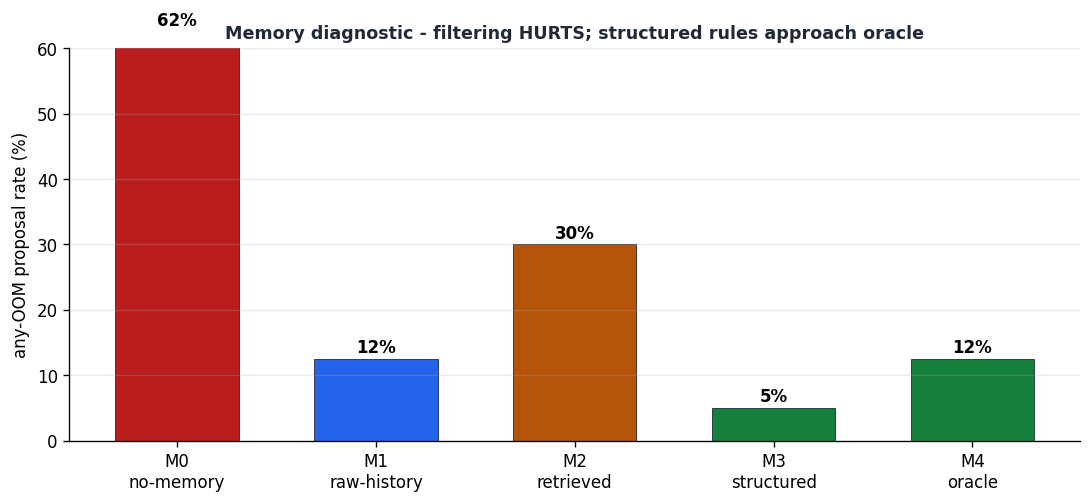

In [3]:
# Reads results/phase3_diagnostic_v3.json (searches candidate dirs); placeholder if absent.
import json, statistics
from pathlib import Path
import matplotlib.pyplot as plt
_cands=[]
try: _cands.append(Path(RESULTS_DIR))
except NameError: pass
_cands += [p/"results" for p in [Path.cwd(), *Path.cwd().parents] if (p/"results").is_dir()]
_f = next((c/"phase3_diagnostic_v3.json" for c in _cands if (c/"phase3_diagnostic_v3.json").exists()), None)
if not _f:
    print("No phase3_diagnostic_v3.json found - run the diagnostic cell above first.")
else:
    d = json.load(open(_f))
    order=["M0_no_memory","M1_raw_history","M2_retrieved","M3_structured","M4_oracle"]
    lab  =["M0\nno-memory","M1\nraw-history","M2\nretrieved","M3\nstructured","M4\noracle"]
    rate =[statistics.mean([r["any_oom_proposal_rate"] for r in d["results"] if r["condition"]==c])*100 for c in order]
    cols =["#B91C1C","#2563EB","#B45309","#15803D","#15803D"]
    fig,ax=plt.subplots(figsize=(9.2,4.3),dpi=120)
    b=ax.bar(lab,rate,color=cols,edgecolor="#1F2937",linewidth=0.5,width=0.62)
    for r,v in zip(b,rate): ax.text(r.get_x()+r.get_width()/2,v+1,f"{v:.0f}%",ha="center",weight="bold")
    ax.set_ylim(0,60); ax.set_ylabel("any-OOM proposal rate (%)")
    ax.set_title("Memory diagnostic - filtering HURTS; structured rules approach oracle",color="#1F2937",weight="bold",fontsize=10.5)
    ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y",alpha=0.25)
    fig.tight_layout(); plt.show()

### 📊 Visualize — M0–M4 memory diagnostic (live JSON)

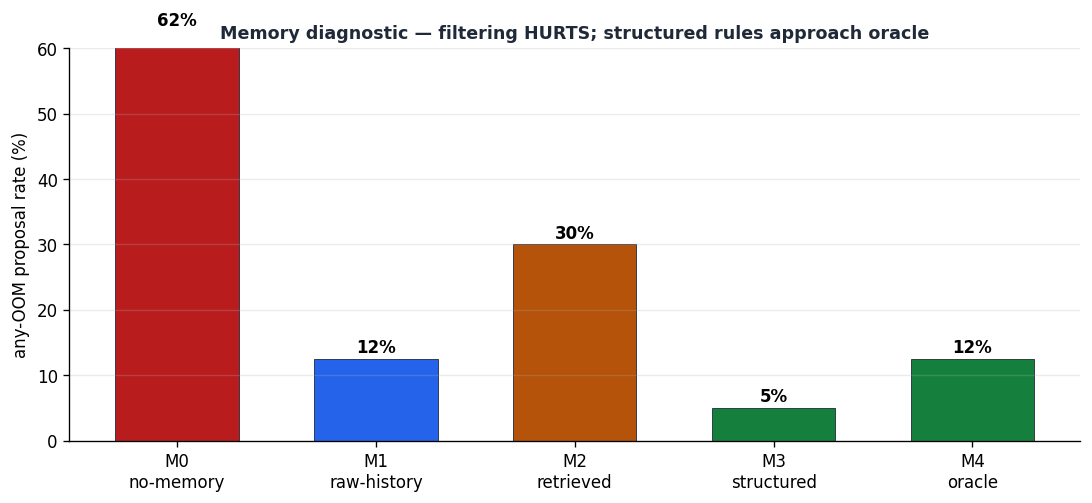

In [4]:
# Reads results/phase3_diagnostic_v3.json; placeholder if absent.
import json, statistics
from pathlib import Path
import matplotlib.pyplot as plt
try: _R = Path(RESULTS_DIR)
except NameError:
    _R = next((p/"results" for p in [Path.cwd(), *Path.cwd().parents] if (p/"results").is_dir()), Path.cwd()/"results")
_f = _R / "phase3_diagnostic_v3.json"
if not _f.exists():
    print("No phase3_diagnostic_v3.json — run the diagnostic cell above first.")
else:
    d = json.load(open(_f))
    order=["M0_no_memory","M1_raw_history","M2_retrieved","M3_structured","M4_oracle"]
    lab  =["M0\nno-memory","M1\nraw-history","M2\nretrieved","M3\nstructured","M4\noracle"]
    rate =[statistics.mean([r["any_oom_proposal_rate"] for r in d["results"] if r["condition"]==c])*100 for c in order]
    cols =["#B91C1C","#2563EB","#B45309","#15803D","#15803D"]
    fig,ax=plt.subplots(figsize=(9.2,4.3),dpi=120)
    b=ax.bar(lab,rate,color=cols,edgecolor="#1F2937",linewidth=0.5,width=0.62)
    for r,v in zip(b,rate): ax.text(r.get_x()+r.get_width()/2,v+1,f"{v:.0f}%",ha="center",weight="bold")
    ax.set_ylim(0,60); ax.set_ylabel("any-OOM proposal rate (%)")
    ax.set_title("Memory diagnostic — filtering HURTS; structured rules approach oracle",color="#1F2937",weight="bold",fontsize=10.5)
    ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y",alpha=0.25)
    fig.tight_layout(); plt.show()